# GNN Source-Zone Workflow

Experimental notebook for source-zone mapping with a simple graph neural network.

Idea: each valid DEM cell is a graph node. D8 downslope flow links define graph edges. The model predicts source-zone probability for each cell.

## 1. Setup

In [8]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

REPO = Path("/home/abdullah/pci-source-zones")
sys.path.insert(0, str(REPO / "src"))

from pci_source_zones.config import load_config, output_path, resolve_path
from pci_source_zones.inputs import read_raster, write_raster
from pci_source_zones.source_area import write_binary_raster

cfg = load_config(REPO / "config" / "montecito.yaml")

OUT = Path("/mnt/c/Users/amehedi/Downloads/source_area_workflow")
OUT.mkdir(parents=True, exist_ok=True)

print("repo:", REPO)
print("outputs:", OUT)

repo: /home/abdullah/pci-source-zones
outputs: /mnt/c/Users/amehedi/Downloads/source_area_workflow


# target controls
SOURCE_C = 20
CHANNEL_C = 120
DOD_THRESHOLD = -0.277

# model controls
HIDDEN = 32
EPOCHS = 60
LEARNING_RATE = 1e-3
PROB_THRESHOLD = 0.50
RANDOM_SEED = 42

# AlphaEarth controls
# This can be a multiband AlphaEarth embedding raster.
# The notebook will reproject/resample it to the DEM grid.
USE_ALPHAEARTH = True
ALPHAEARTH_PATH = Path("/mnt/c/Users/amehedi/Downloads/pioneer/output/alphaearth_2023_pioneer_aligned_30m.tif")
ALPHAEARTH_MAX_BANDS = 16   # use 16 first for speed; change to 64 for all bands

# split controls
# use "random" for quick testing, or "polygon" for polygon 3 train / polygon 4 test
SPLIT_MODE = "random"
POLYGON_PATH = Path("/mnt/c/Users/amehedi/Downloads/dunne_lithology_polygons_unlabeled.gpkg")
TRAIN_POLY_ID = 3
TEST_POLY_ID = 4


In [9]:
# target controls
SOURCE_C = 20
CHANNEL_C = 120
DOD_THRESHOLD = -0.277

# model controls
HIDDEN = 32
EPOCHS = 60
LEARNING_RATE = 1e-3
PROB_THRESHOLD = 0.50
RANDOM_SEED = 42

# AlphaEarth controls
# This can be a multiband AlphaEarth embedding raster.
# The notebook will reproject/resample it to the DEM grid.
USE_ALPHAEARTH = True
ALPHAEARTH_PATH = Path("/mnt/c/Users/amehedi/Downloads/pioneer/output/alphaearth_2023_pioneer_aligned_30m.tif")
ALPHAEARTH_MAX_BANDS = 16   # use 16 first for speed; change to 64 for all bands

# split controls
# use "random" for quick testing, or "polygon" for polygon 3 train / polygon 4 test
SPLIT_MODE = "random"
POLYGON_PATH = Path("/mnt/c/Users/amehedi/Downloads/dunne_lithology_polygons_unlabeled.gpkg")
TRAIN_POLY_ID = 3
TEST_POLY_ID = 4


## 3. Load Rasters and Target

In [10]:
dem, profile = read_raster(resolve_path(cfg, cfg["paths"]["dem"]))
dem_diff, _ = read_raster(resolve_path(cfg, cfg["paths"]["dem_diff"]))

G, _ = read_raster(output_path(cfg, "topographic_driving_index", "topographic_driving_index.tif"))
S, _ = read_raster(output_path(cfg, "slope", "slope.tif"))
a, _ = read_raster(output_path(cfg, "specific_catchment_area", "specific_catchment_area.tif"))

cell_size = abs(profile["transform"].a)
DA = a * cell_size

valid = np.isfinite(dem) & np.isfinite(G) & np.isfinite(S) & np.isfinite(DA) & np.isfinite(dem_diff) & (S > 0) & (DA > 0)

Y = (
    valid &
    (G >= SOURCE_C) &
    (G < CHANNEL_C) &
    (dem_diff < DOD_THRESHOLD)
).astype("uint8")

print("valid cells:", int(valid.sum()))
print("target source cells:", int(Y.sum()))

valid cells: 528827
target source cells: 44930


## 4. Build D8 Flow Graph

Edges connect each cell to its steepest downslope neighbor. Reverse edges are also added so the GNN can pass information both upstream and downstream.

In [11]:
node_id = np.full(dem.shape, -1, dtype="int64")
node_id[valid] = np.arange(valid.sum(), dtype="int64")

def make_d8_edges(dem, valid, node_id):
    rows, cols = dem.shape
    best_drop = np.zeros(dem.shape, dtype="float64")
    rec_r = np.full(dem.shape, -1, dtype="int32")
    rec_c = np.full(dem.shape, -1, dtype="int32")

    offsets = [
        (-1, -1, np.sqrt(2)), (-1, 0, 1.0), (-1, 1, np.sqrt(2)),
        (0, -1, 1.0),                    (0, 1, 1.0),
        (1, -1, np.sqrt(2)),  (1, 0, 1.0),  (1, 1, np.sqrt(2)),
    ]

    for dr, dc, dist in offsets:
        rs0 = max(0, -dr)
        rs1 = rows - max(0, dr)
        cs0 = max(0, -dc)
        cs1 = cols - max(0, dc)

        rn0 = rs0 + dr
        rn1 = rs1 + dr
        cn0 = cs0 + dc
        cn1 = cs1 + dc

        center = dem[rs0:rs1, cs0:cs1]
        neigh = dem[rn0:rn1, cn0:cn1]
        drop = (center - neigh) / dist

        ok = (
            valid[rs0:rs1, cs0:cs1] &
            valid[rn0:rn1, cn0:cn1] &
            np.isfinite(drop) &
            (drop > best_drop[rs0:rs1, cs0:cs1]) &
            (drop > 0)
        )

        br = best_drop[rs0:rs1, cs0:cs1]
        rr = rec_r[rs0:rs1, cs0:cs1]
        cc = rec_c[rs0:rs1, cs0:cs1]

        neigh_rows = np.arange(rn0, rn1)[:, None] + np.zeros((rn1 - rn0, cn1 - cn0), dtype="int32")
        neigh_cols = np.zeros((rn1 - rn0, cn1 - cn0), dtype="int32") + np.arange(cn0, cn1)[None, :]

        br[ok] = drop[ok]
        rr[ok] = neigh_rows[ok]
        cc[ok] = neigh_cols[ok]

    has_receiver = valid & (rec_r >= 0)
    src0 = node_id[has_receiver]
    dst0 = node_id[rec_r[has_receiver], rec_c[has_receiver]]
    keep = (src0 >= 0) & (dst0 >= 0) & (src0 != dst0)

    src0 = src0[keep]
    dst0 = dst0[keep]

    edge_src = np.concatenate([src0, dst0])
    edge_dst = np.concatenate([dst0, src0])

    return edge_src.astype("int64"), edge_dst.astype("int64")

edge_src, edge_dst = make_d8_edges(dem, valid, node_id)

print("nodes:", int(valid.sum()))
print("edges:", len(edge_src))

nodes: 528827
edges: 1056726


## 5. Choose Features

`log_G` is available but excluded by default because the target is partly built from `G`.

In [14]:
THOMAS = Path("/mnt/c/Users/amehedi/Downloads/thomas")

# Safe defaults in case the Controls cell was not run.
USE_ALPHAEARTH = globals().get("USE_ALPHAEARTH", True)
ALPHAEARTH_PATH = globals().get(
    "ALPHAEARTH_PATH",
    Path("/mnt/c/Users/amehedi/Downloads/pioneer/output/alphaearth_2023_pioneer_aligned_30m.tif"),
)
ALPHAEARTH_MAX_BANDS = globals().get("ALPHAEARTH_MAX_BANDS", 16)

# np.where evaluates both branches, so use explicit safe log arrays.
log_DA = np.full(DA.shape, np.nan, dtype="float32")
log_DA[DA > 0] = np.log10(DA[DA > 0])

log_G = np.full(G.shape, np.nan, dtype="float32")
log_G[G > 0] = np.log10(G[G > 0])

raw_features = {
    "S": S,
    "log_DA": log_DA,
    "log_G": log_G,
}

feature_paths = {
    "burn_severity": THOMAS / "burn__severity.tif",
    "soil_texture": THOMAS / "soil__texture.tif",
    "soil_thickness": THOMAS / "soil__thickness.tif",
    "soil_density": THOMAS / "soil__density.tif",
    "sand_total": THOMAS / "sand__total.tif",
    "silt_total": THOMAS / "silt__total.tif",
    "clay_total": THOMAS / "clay__total.tif",
    "porosity": THOMAS / "porosity.tif",
    "pH": THOMAS / "pH.tif",
    "field_capacity": THOMAS / "field__capacity.tif",
    "saturated_water_content": THOMAS / "saturated__water_content.tif",
    "soil_transmissivity": THOMAS / "soil__transmissivity.tif",
    "hydraulic_conductivity": THOMAS / "soil__saturated_hydraulic_conductivity.tif",
    "cation_exchange_capacity": THOMAS / "cation__exchange_capacity.tif",
    "landcover": THOMAS / "landcover.tif",
}

for name, path in feature_paths.items():
    if path.exists():
        arr, _ = read_raster(path)
        if arr.shape == G.shape:
            raw_features[name] = arr
        else:
            print("skipped shape mismatch:", name, arr.shape)
    else:
        print("missing:", path)

# Optional AlphaEarth multiband features.
# These are foundation-model embeddings, so each band becomes one input feature.
def add_alphaearth_features(path, max_bands=16):
    import rasterio
    from rasterio.warp import reproject, Resampling

    path = Path(path)
    if not path.exists():
        print("AlphaEarth raster missing:", path)
        return []

    added = []
    with rasterio.open(path) as src:
        n_bands = min(src.count, int(max_bands))
        print("AlphaEarth raster:", path)
        print("AlphaEarth bands used:", n_bands, "of", src.count)
        print("AlphaEarth source shape/crs:", (src.height, src.width), src.crs)

        for band in range(1, n_bands + 1):
            source = src.read(band).astype("float32")
            dst = np.full(G.shape, -9999.0, dtype="float32")

            reproject(
                source=source,
                destination=dst,
                src_transform=src.transform,
                src_crs=src.crs,
                src_nodata=src.nodata,
                dst_transform=profile["transform"],
                dst_crs=profile["crs"],
                dst_nodata=-9999.0,
                resampling=Resampling.bilinear,
            )

            dst = np.where(dst == -9999.0, np.nan, dst)
            if np.isfinite(dst[valid]).sum() == 0:
                continue

            name = f"alphaearth_{band:02d}"
            raw_features[name] = dst
            added.append(name)

    if len(added) == 0:
        print("No AlphaEarth bands overlapped the DEM/AOI, so none were added.")
    else:
        print("added AlphaEarth features:", len(added))

    return added

alphaearth_names = []
if USE_ALPHAEARTH:
    alphaearth_names = add_alphaearth_features(ALPHAEARTH_PATH, ALPHAEARTH_MAX_BANDS)

feature_names = [
    "S",
    "log_DA",
    # "log_G",  # optional, but can leak the physics rule into the model
    "burn_severity",
    "soil_texture",
    "soil_thickness",
    "soil_density",
    "sand_total",
    "silt_total",
    "clay_total",
    "porosity",
    "field_capacity",
    "saturated_water_content",
    "hydraulic_conductivity",
    "landcover",
]

# Add AlphaEarth bands after the ordinary terrain/soil/burn features.
feature_names = feature_names + alphaearth_names

feature_names = [name for name in feature_names if name in raw_features]
print("total features:", len(feature_names))
print("features:", feature_names)


/tmp/ipykernel_7071/672443106.py:5: RuntimeWarning: divide by zero encountered in log10
  "log_DA": np.where(DA > 0, np.log10(DA), np.nan),
/tmp/ipykernel_7071/672443106.py:6: RuntimeWarning: divide by zero encountered in log10
  "log_G": np.where(G > 0, np.log10(G), np.nan),


NameError: name 'USE_ALPHAEARTH' is not defined

## 6. Build Node Feature Matrix

In [ ]:
X_list = []

for name in feature_names:
    arr = raw_features[name].astype("float32")
    vals = arr[valid & np.isfinite(arr)]

    med = float(np.nanmedian(vals))
    std = float(np.nanstd(vals))
    if std == 0 or not np.isfinite(std):
        std = 1.0

    arr = np.where(np.isfinite(arr), arr, med)
    arr = (arr - med) / std
    X_list.append(arr[valid].astype("float32"))

X_node = np.stack(X_list, axis=1)
Y_node = Y[valid].astype("float32")

print("X_node:", X_node.shape)
print("Y_node:", Y_node.shape, "positive:", int(Y_node.sum()))

X_node: (528827, 14)
Y_node: (528827,) positive: 44930


## 7. Train/Test Split

In [ ]:
rng = np.random.default_rng(RANDOM_SEED)

if SPLIT_MODE == "polygon":
    import geopandas as gpd
    from rasterio.features import geometry_mask

    polys = gpd.read_file(POLYGON_PATH).to_crs(profile["crs"])
    train_geom = polys[polys["poly_id"] == TRAIN_POLY_ID].geometry
    test_geom = polys[polys["poly_id"] == TEST_POLY_ID].geometry

    train_raster = geometry_mask(train_geom, out_shape=Y.shape, transform=profile["transform"], invert=True) & valid
    test_raster = geometry_mask(test_geom, out_shape=Y.shape, transform=profile["transform"], invert=True) & valid

    train_mask = train_raster[valid]
    test_mask = test_raster[valid]
else:
    r = rng.random(Y_node.shape)
    train_mask = r < 0.80
    test_mask = r >= 0.80

train_idx = np.where(train_mask)[0]
test_idx = np.where(test_mask)[0]

print("train nodes:", len(train_idx), "positive:", int(Y_node[train_idx].sum()))
print("test nodes:", len(test_idx), "positive:", int(Y_node[test_idx].sum()))

train nodes: 423211 positive: 35985
test nodes: 105616 positive: 8945


## 8. Simple GraphSAGE Model

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleGraphSAGE(nn.Module):
    def __init__(self, in_ch, hidden):
        super().__init__()
        self.lin1 = nn.Linear(in_ch * 2, hidden)
        self.lin2 = nn.Linear(hidden * 2, hidden)
        self.out = nn.Linear(hidden, 1)

    def aggregate(self, x, src, dst, n_nodes):
        out = torch.zeros_like(x)
        deg = torch.zeros(n_nodes, device=x.device)

        out.index_add_(0, dst, x[src])
        deg.index_add_(0, dst, torch.ones_like(dst, dtype=torch.float32))

        return out / deg.clamp(min=1).unsqueeze(1)

    def forward(self, x, src, dst):
        n_nodes = x.shape[0]

        neigh = self.aggregate(x, src, dst, n_nodes)
        h = F.relu(self.lin1(torch.cat([x, neigh], dim=1)))

        neigh = self.aggregate(h, src, dst, n_nodes)
        h = F.relu(self.lin2(torch.cat([h, neigh], dim=1)))

        return self.out(h).squeeze(1)

device = "cuda" if torch.cuda.is_available() else "cpu"

x_tensor = torch.tensor(X_node, dtype=torch.float32).to(device)
y_tensor = torch.tensor(Y_node, dtype=torch.float32).to(device)
src_tensor = torch.tensor(edge_src, dtype=torch.long).to(device)
dst_tensor = torch.tensor(edge_dst, dtype=torch.long).to(device)
train_tensor = torch.tensor(train_idx, dtype=torch.long).to(device)
test_tensor = torch.tensor(test_idx, dtype=torch.long).to(device)

model = SimpleGraphSAGE(in_ch=X_node.shape[1], hidden=HIDDEN).to(device)

pos = float(Y_node[train_idx].sum())
neg = float(len(train_idx) - pos)
pos_weight = torch.tensor([neg / max(pos, 1.0)], dtype=torch.float32).to(device)

loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print("device:", device)
print("pos_weight:", float(pos_weight.cpu().numpy()[0]))

NameError: name 'X_node' is not defined

## 9. Train

In [13]:
for epoch in range(EPOCHS):
    model.train()

    optimizer.zero_grad()
    logits = model(x_tensor, src_tensor, dst_tensor)
    loss = loss_fn(logits[train_tensor], y_tensor[train_tensor])
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print("epoch", epoch + 1, "loss", float(loss.detach().cpu().numpy()))

NameError: name 'model' is not defined

## 10. Evaluate

In [7]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

model.eval()
with torch.no_grad():
    logits = model(x_tensor, src_tensor, dst_tensor)
    prob_node = torch.sigmoid(logits).cpu().numpy().astype("float32")

pred_node = (prob_node >= PROB_THRESHOLD).astype("uint8")

y_true = Y_node[test_idx].astype("uint8")
y_pred = pred_node[test_idx].astype("uint8")

print("test nodes:", len(y_true))
print("confusion matrix:")
print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, zero_division=0))

print("accuracy:", accuracy_score(y_true, y_pred))
print("precision:", precision_score(y_true, y_pred, zero_division=0))
print("recall:", recall_score(y_true, y_pred, zero_division=0))
print("f1:", f1_score(y_true, y_pred, zero_division=0))

NameError: name 'model' is not defined

## 11. Export Maps

In [11]:
prob_map = np.full(G.shape, np.nan, dtype="float32")
class_map = np.zeros(G.shape, dtype="uint8")

prob_map[valid] = prob_node
class_map[valid] = pred_node

prob_path = OUT / f"gnn_probability_C{SOURCE_C}_lt_channel_C{CHANNEL_C}.tif"
class_path = OUT / f"gnn_class_C{SOURCE_C}_lt_channel_C{CHANNEL_C}_p{str(PROB_THRESHOLD).replace('.', 'p')}.tif"

write_raster(prob_path, prob_map, profile)
write_binary_raster(class_path, class_map, profile)

print("saved:", prob_path)
print("saved:", class_path)

saved: /mnt/c/Users/amehedi/Downloads/source_area_workflow/gnn_probability_C20_lt_channel_C120.tif
saved: /mnt/c/Users/amehedi/Downloads/source_area_workflow/gnn_class_C20_lt_channel_C120_p0p5.tif


## 12. Quick Plot

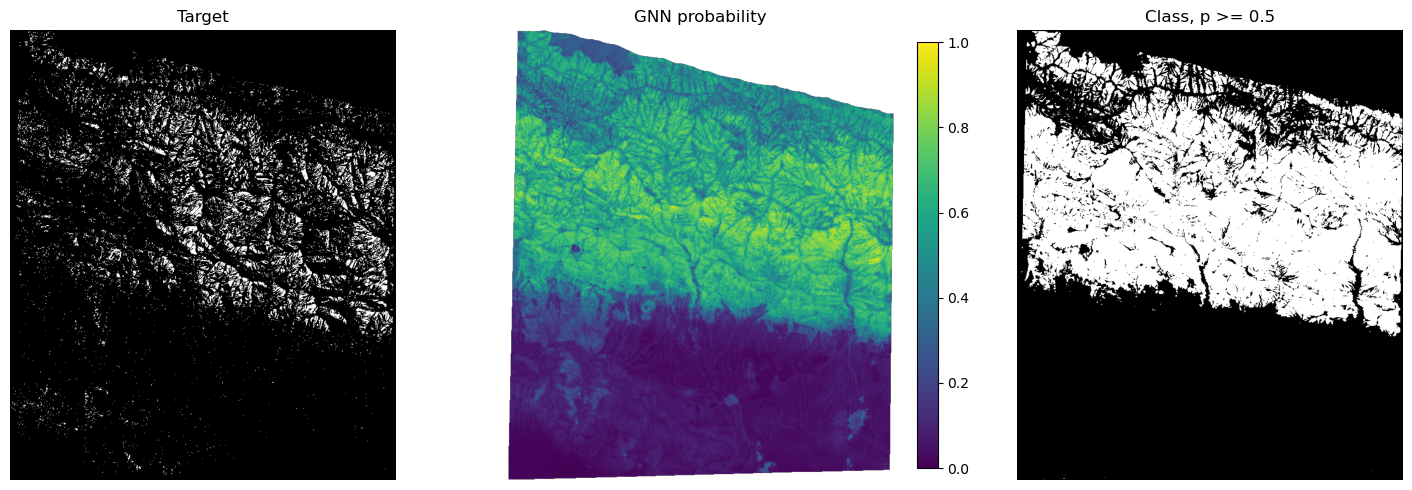

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(Y, cmap="gray")
axes[0].set_title("Target")

im = axes[1].imshow(prob_map, cmap="viridis", vmin=0, vmax=1)
axes[1].set_title("GNN probability")
plt.colorbar(im, ax=axes[1], fraction=0.046)

axes[2].imshow(class_map, cmap="gray")
axes[2].set_title(f"Class, p >= {PROB_THRESHOLD}")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()